# LC
 
## Fig 1. in the paper
 - Three examples for paper \
 Fig. 1 - definitely a bigger font - rule of thumb is that fonts in figures should be of comparable size with the main text;
I'd stick to python's default colors, i.e., default blue and orange - they are chosen as such to be color-blind friendly, and A&A editors pay attention to it.
I'd also add on all panels a horizontal, dashed, gray line at 10^-6 to indicate the threshold.
MJD should have units, i.e., x-axis lable should read "MJD [d]" or "MJD [days]".

# コード
## Utility: 
###  - LCファイル名一覧の取得

In [124]:
import os

def get_lc_files(dir_path_lc= "./data_LC/14d"): 
    filenames= [
        f for f in os.listdir(dir_path_lc) if os.path.isfile(os.path.join(dir_path_lc, f))
    ]
    # print(filenames)
    return filenames

In [125]:
get_lc_files()

['4fgl_j1427.9-4206_lightcurve.fits',
 '4fgl_j1512.8-0906_lightcurve.fits',
 '4fgl_j0957.6+5523_lightcurve.fits',
 '4fgl_j0428.6-3756_lightcurve.fits',
 '4fgl_j2253.9+1609_lightcurve.fits',
 '4fgl_j2232.6+1143_lightcurve.fits',
 '4fgl_j0457.0-2324_lightcurve.fits',
 '4fgl_j1833.6-2103_lightcurve.fits',
 '4fgl_j1159.5+2914_lightcurve.fits',
 '4fgl_j0721.9+7120_lightcurve.fits',
 '4fgl_j1504.4+1029_lightcurve.fits',
 '4fgl_j0348.6-2749_lightcurve.fits',
 '4fgl_j0210.7-5101_lightcurve.fits',
 '4fgl_j2202.7+4216_lightcurve.fits',
 '4fgl_j1104.4+3812_lightcurve.fits',
 '4fgl_j1224.9+2122_lightcurve.fits',
 '4fgl_j0112.1+2245_lightcurve.fits',
 '4fgl_j1256.1-0547_lightcurve.fits',
 '4fgl_j2158.8-3013_lightcurve.fits',
 '4fgl_j0108.6+0134_lightcurve.fits',
 '4fgl_j0538.8-4405_lightcurve.fits']

### - 天体名対応辞書作成

In [126]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit') # MacBook
  # hdu=fits.open('/home/kazuma/Workspace/Fermi/gll_psc_v35.fit') # Legion
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map] # data['ASSOC1']
  sources_blazars2 = sources2[element_map] # data['ASSOC2']
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  
  
  sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


In [127]:
def get_dict_sourcenames_updated():
  dict_sourcename = get_dict_sourcenames()

  dict_sourcename[0]['assoc name']  = '3C 454.3' 
  dict_sourcename[1]['assoc name']  = 'Mrk 421' 
  dict_sourcename[2]['assoc name']  = 'BL Lac' 
  dict_sourcename[3]['assoc name']  = 'CTA 102' 
  dict_sourcename[4]['assoc name']  = '3C 279'
  dict_sourcename[5]['assoc name']  = 'S5 0716+71' 
  dict_sourcename[6]['assoc name']  = 'PKS 1424-41' 
  dict_sourcename[7]['assoc name']  = 'PKS 0426-380'
  dict_sourcename[8]['assoc name']  = 'PKS 0537-441'
  dict_sourcename[9]['assoc name']  = 'PKS 2155-304'
  dict_sourcename[10]['assoc name'] = 'PKS 0454-234'
  dict_sourcename[11]['assoc name'] = 'PKS 1510-089'
  dict_sourcename[12]['assoc name'] = 'PKS 1502+106'
  dict_sourcename[13]['assoc name'] = 'TON 599'
  dict_sourcename[14]['assoc name'] = 'PKS 0346-27'
  dict_sourcename[15]['assoc name'] = '4C +01.02'
  dict_sourcename[16]['assoc name'] = '4C +55.17'
  dict_sourcename[17]['assoc name'] = '4C +21.35'
  dict_sourcename[18]['assoc name'] = 'PKS 1830-211'
  dict_sourcename[19]['assoc name'] = 'PKS 0208-512'
  dict_sourcename[0:15]
  return dict_sourcename

In [128]:
dict_sourcename = get_dict_sourcenames()
# dict_sourcename[0:15]
dict_sourcename[200:215]

# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0112.1+2245']# dict_sourcename[(dict_sourcename['4FGL name'] == '4fgl_j0112.1+2245')]

4FGL name,assoc name,CLASS,index
str18,str28,str4,int64
4fgl_j0102.8+5824,txs_0059+581,FSRQ,201
4fgl_j0133.1-5201,pks_0131-522,FSRQ,202
4fgl_j1120.8+4212,rbs_0970,BLL,203
4fgl_j0533.3+4823,txs_0529+483,FSRQ,204
4fgl_j0622.3-2605,pmn_j0622-2605,BLL,205
4fgl_j0510.0+1800,pks_0507+17,FSRQ,206
4fgl_j1630.7+5221,txs_1629+524,BLL,207
4fgl_j1316.1-3338,pks_1313-333,FSRQ,208
4fgl_j1448.0+3608,rbs_1432,BLL,209


In [129]:
# mask = (dict_sourcename['assoc name'] == 'gb6 j1040+0617') 
mask = (dict_sourcename['4FGL name'] == '4fgl_j1040.5+0617') 
# mask = (dict_sourcename['4FGL name'] == '4fgl_j0348.6-2749') 
dict_sourcename[mask]


4FGL name,assoc name,CLASS,index
str18,str28,str4,int64
4fgl_j1040.5+0617,gb6_j1040+0617,BLL,713


In [130]:
mask = (dict_sourcename['assoc name'] == 'txs_0506+056') 
# mask = (dict_sourcename['4FGL name'] == '4fgl_j1040.5+0617') 
dict_sourcename[mask]

4FGL name,assoc name,CLASS,index
str18,str28,str4,int64
4fgl_j0509.4+0542,txs_0506+056,BLL,55


In [131]:
mask = (dict_sourcename['4FGL name'] == '4fgl_j0348.6-2749')
dict_sourcename[mask]
# dict_sourcename[14]
# mask
# dict_sourcename[14]['4FGL name']= '4fgl_j0348.5-2749'
# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0348.5-2749']
# dict_sourcename['4FGL name'] == '4fgl_j0348.5-2749'
# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0348.6-2749']


4FGL name,assoc name,CLASS,index
str18,str28,str4,int64
4fgl_j0348.6-2749,pks_0346-27,FSRQ,15


# LCの描画
## 全LCの描画

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

for file in file_list:
    if file.endswith('.fits'):
        lc_tab = Table.read(os.path.join(lc_file_dir, file))
        # Add a new column with the average of tmax_mjd and tmin_mjd
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        # # Save the modified table back to a new fits file
        # lc_tab.write(os.path.join(lc_file_dir, f'modified_{file}'), overwrite=True)
        # fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
        sourcename_4fgl = file.split('_')[1] # Extract the 4FGL name from the filename
        sourceinfo = dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_' + sourcename_4fgl]
        print(sourcename_4fgl)
        sourcename_assoc = sourceinfo['assoc name'].data[0]
        sourceindex = sourceinfo['index'].data[0]
        print('4fgl_' + sourcename_4fgl + ':' + str(sourcename_assoc) + ' ' + str(sourceindex))
        # print(sourcename_assoc)
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']
        plt.plot(lc_x,lc_y ,marker='o',label=sourcename_assoc)

# lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
# plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
plt.legend()
plt.show()
plt.tight_layout()


## 選択的に描画（明るさ順指定可能）

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

plot_refsource = True
if plot_refsource:
 # Plot the light curve of the reference source
  dict_sourcename = get_dict_sourcenames_updated()
  # print(dict_sourcename)
  # print(dict_sourcename[0])
  # print(dict_sourcename[0]['4FGL name'])
  # print(dict_sourcename[0]['assoc name'])
  # print(dict_sourcename[0]['index'])
  source = dict_sourcename[0]
  print(source)
  lc_tab = Table.read(os.path.join(lc_file_dir, source['4FGL name'] + '_lightcurve.fits'))
  lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
  lc_x=lc_tab['t_mjd']
  lc_y=lc_tab['flux']
  plt.plot(lc_x,lc_y ,marker='o',color= 'red', label=source['assoc name'])



for source in dict_sourcename[11:14]:
  print(source)
  lc_tab = Table.read(os.path.join(lc_file_dir, source['4FGL name'] + '_lightcurve.fits'))
  lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
  lc_x=lc_tab['t_mjd']
  lc_y=lc_tab['flux']
  plt.plot(lc_x,lc_y ,marker='o',label=source['assoc name'])

plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
# plt.xlim(57790-14*20-5, 57790+14*20+5)  # Adjust the x-axis limits to show a 14-day window around MJD 57790
plt.legend()
plt.show()
plt.tight_layout()

# 1d SED描画可能性検証



In [134]:
lc_file_dir = 'data_LC/1d'
file_list = get_lc_files(lc_file_dir) 
print(file_list)
dict_source = get_dict_sourcenames()
dict_source[dict_sourcename['assoc name'] == '3c_454.3']



['4fgl_j0108.6+0134_lightcurve_all.fits', '4fgl_j1256.1-0547_lightcurve_all.fits', '4fgl_j2202.7+4216_lightcurve2.fits', '4fgl_j2253.9+1609_lightcurve_all.fits', '4fgl_j2253.9+1609_lightcurve2.fits', '4fgl_j1040.5+0617_lightcurve_30min.fits', '4fgl_j1512.8-0906_lightcurve_all.fits', '4fgl_j1040.5+0617_lightcurve_2min.fits', '4fgl_j1833.6-2103_lightcurve1.fits', '4fgl_j1427.9-4206_lightcurve_all.fits', '4fgl_j1224.9+2122_lightcurve_all.fits', '4fgl_j2232.6+1143_lightcurve2.fits', '4fgl_j1159.5+2914_lightcurve_all.fits', '4fgl_j1256.1-0547_lightcurve1.fits', '4fgl_j2232.6+1143_lightcurve3.fits', '4fgl_j1833.6-2103_lightcurve_all.fits', '4fgl_j1040.5+0617_lightcurve_10min.fits', '4fgl_j1256.1-0547_lightcurve2.fits', '4fgl_j2202.7+4216_lightcurve_all.fits', '4fgl_j1040.5+0617_lightcurve.fits', '4fgl_j0348.6-2749_lightcurve_all.fits', '4fgl_j2232.6+1143_lightcurve_7d.fits', '4fgl_j1040.5+0617_lightcurve_1h.fits', '4fgl_j2232.6+1143_lightcurve1.fits', '4fgl_j2232.6+1143_lightcurve_all.fits',

4FGL name,assoc name,CLASS,index
str18,str28,str4,int64


### - 1d LC ファイル読込
### - SED ecsv ファイル読込
### - 存否検索・列追加
### - 1d LC の描画

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os
lc_file_dir = 'data_LC/1d'
source = dict_source[dict_source['assoc name'] == '3c_454.3']
print(source['4FGL name'].data[0])

###########################
### Read the data       ###
###########################
# LC
# lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve1.fits')
lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve2.fits')
lc_tab = Table.read(lc_filepath)

# SED
# sed_filepath = 'data/3C454.3_allsed_1d_min11.ecsv'
sed_filepath = 'data/3C454.3_allsed_1d_2_min11.ecsv'
sed_tab_0 = Table.read(sed_filepath)
nonzero_mask = (sed_tab_0['e2dnde'] > sed_tab_0['e2dnde_err'])
sed_tab = sed_tab_0[nonzero_mask]

lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
# plt.plot(lc_x,lc_y ,marker='o',color= 'blue', label=source['assoc name'])



###########################
###    データ整形         ###
###########################
obsdates_sed=np.round(np.unique(sed_tab['tstart'].data).tolist(),3)
obsdates_lc=np.round(lc_tab['tmin_mjd'],3)
array_validseds = []
for idx, obsdate_lc in enumerate(obsdates_lc):
  # print(idx, ': obsdate',obsdate_lc)
  mask = (obsdates_sed==obsdate_lc)
  if mask.sum() > 0:
    # print('obsdate', obsdate_lc, '---', mask.sum() )
    # print(lc_tab[idx])
    array_validseds.append(True)
  else:
    # print('obsdate', obsdate_lc)
    array_validseds.append(False)
from astropy.table import Column
lc_tab.add_column(array_validseds, name='ValidSED', index=0)
print(lc_tab)



###########################
###    描画              ###
###########################
### Light Curve ###
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
plt.plot(lc_x,lc_y ,marker='o',label="Full Light Curve")

mask = (lc_tab['ValidSED'] == True)
lc_x=lc_tab[mask]['t_mjd']
lc_y=lc_tab[mask]['flux']
plt.plot(lc_x,lc_y ,marker='o', linestyle='', label="Valid SEDs")


plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
# plt.xlim(57790-14*20-5, 57790+14*20+5)  # Adjust the x-axis limits to show a 14-day window around MJD 57790
plt.legend()
plt.show()
plt.tight_layout()

### Histogram of fluxes ###
hist_valid = plt.hist(np.log10(lc_tab[mask]['flux'].data), bins=np.arange(-6.5, -4.0, 0.1),histtype='step', lw=2, label='Valid SED')
hist_valid = plt.hist(np.log10(lc_tab[np.invert(mask)]['flux'].data), bins=np.arange(-6.5, -4.0, 0.1),histtype='step', lw=2, label='Invalid SED')
plt.legend()
print(lc_tab[mask]['flux'][0:10])
print(np.log10(lc_tab[mask]['flux'][0:10]))



In [136]:
print(pow(10,-5.8))
print(pow(10,-5.9))




1.584893192461114e-06
1.2589254117941661e-06


## Threshold 適用

In [ ]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

threshold_flux = 1.0e-6  # Define a threshold for flux
lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir)


# Label size parameters
label_size = 15
plt.rcParams.update({'font.size': label_size})

for file in file_list:
    if file.endswith('.fits'):
        lc_tab = Table.read(os.path.join(lc_file_dir, file))
        # Add a new column with the average of tmax_mjd and tmin_mjd
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        mask = (lc_tab['flux'] > threshold_flux) 
        # lc_tab.add_column((mask, name='high state', index=0)

        # fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
        sourcename_4fgl = file.split('_')[1] # Extract the 4FGL name from the filename
        sourceinfo = dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_' + sourcename_4fgl]
        sourcename_assoc = sourceinfo['assoc name'].data[0]
        sourceindex = sourceinfo['index'].data[0]
        print('4fgl_' + sourcename_4fgl + ':' + str(sourcename_assoc) + ' ' + str(sourceindex))
        print(np.round(lc_tab['t_mjd'][mask],1))
        # print(sourcename_assoc)
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']

        fig = plt.figure(figsize=(8, 5))
        plt.plot(lc_x,lc_y ,marker='o',label=f"{sourcename_assoc}, {sourceindex}")
        plt.plot(lc_x[mask], lc_y[mask], marker='o', linestyle='', color='red', label='High State')

        #  add on all panels a horizontal, dashed, gray line at 10^-6 to indicate the threshold.
        plt.axhline(y=threshold_flux, color='gray', linestyle='--', label='Threshold')
        # lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
        # plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
        plt.xlabel('MJD')
        plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
        plt.yscale('log')
        plt.ylim(1e-8, 1e-4)
        plt.legend()

        # plt.show()
        plt.tight_layout()
        plt.savefig(f"figures/lightcurve_{str(sourceindex)}_{str(sourcename_assoc)}.png", dpi=300, bbox_inches='tight')


        



# A&Aフォーマットで描画 (Fig.1)

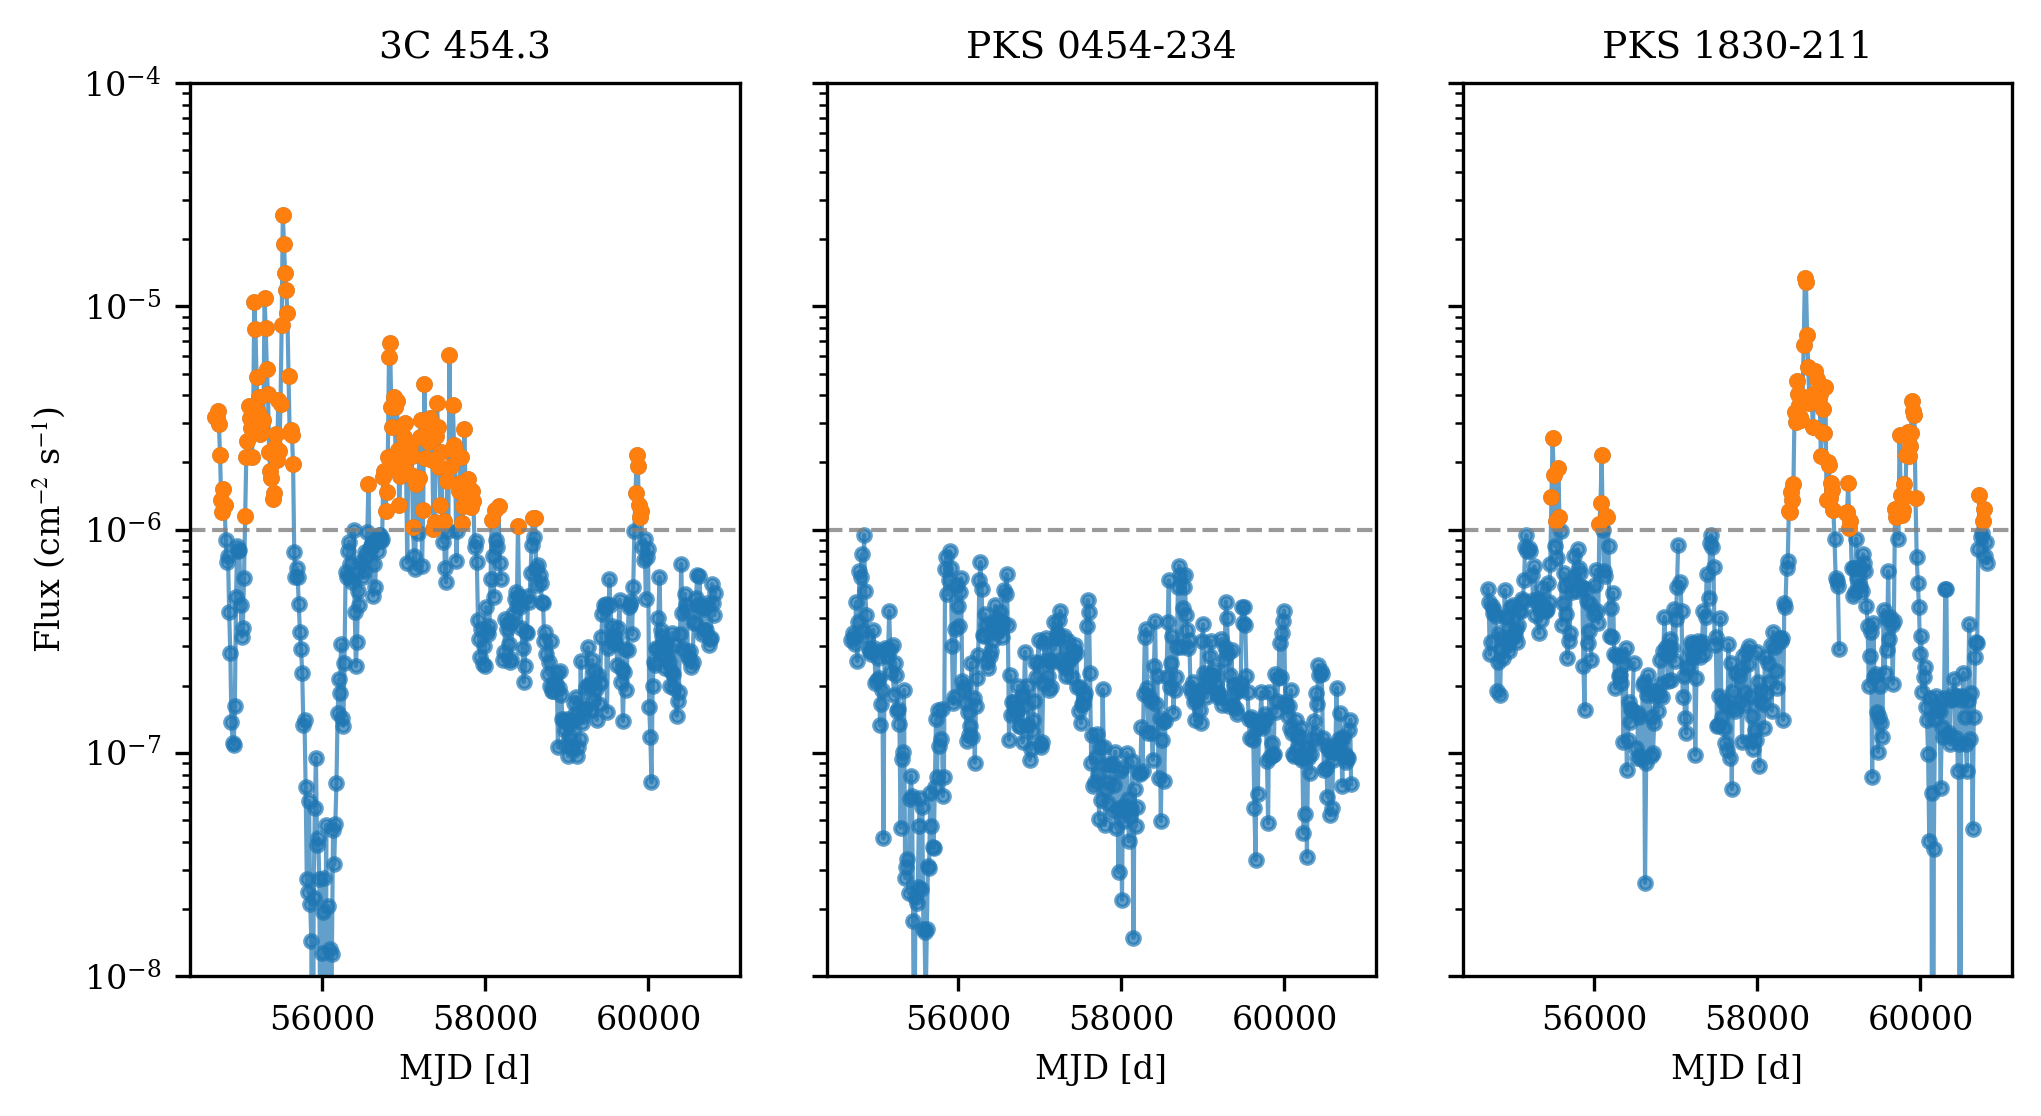

In [138]:
import matplotlib.pyplot as plt
from astropy.table import Table
import os

# Set rcParams for A&A style
# For the axes, the default font size is 10, but we can adjust it for better readability.
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16, # But it doesn't seem to work
    'axes.labelsize': 8,#10,
    'axes.titlesize': 8,#10,
    'xtick.labelsize': 10,#8,
    'ytick.labelsize': 10,#8,
    'legend.fontsize': 10,#8,
    'figure.titlesize': 10, #12,
    'mathtext.fontset': 'stix',  # For LaTeX-like math
    'figure.dpi': 300
})

# A&A single column width: 8.8 cm ≈ 3.46 inches
# For three panels, total width: 18 cm (double column) ≈ 7.09 inches
# Height: 6 inches for good aspect ratio
# fig, axes = plt.subplots(1, 3, figsize=(18/2.54, 6), sharey=True)
fig, axes = plt.subplots(1, 3, figsize=(18/2.54, 4), sharey=True)

threshold_flux = 1.0e-6

# Select three brightest sources (indices 0, 4, 6)
selected_sources = dict_sourcename[[0, 10, 18]]

lc_file_dir = 'data_LC/14d'

for i, source in enumerate(selected_sources):
    ax = axes[i]
    sourcename_4fgl = source['4FGL name']
    lc_filepath = os.path.join(lc_file_dir, sourcename_4fgl + '_lightcurve.fits')
    
    if os.path.exists(lc_filepath):
        lc_tab = Table.read(lc_filepath)
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        
        mask = (lc_tab['flux'] > threshold_flux)
        
        # # Plot full light curve (second in legend)
        # ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=3, linestyle='-', linewidth=1, alpha=0.7, label='Full LC')
        # # get the color of the full light curve line
        # lc_line_color = ax.get_lines()[0].get_color()
        # # Plot high state points (first in legend) 
        # # ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=4,  markerfacecolor=lc_line_color, markeredgecolor='orange', linestyle='', label='High State')
        # ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=4,  markeredgecolor=lc_line_color, linestyle='', label='High State')

        # get the colors of the palette        
        # palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
        # print(palette[0], palette[1], palette[2])
        # # Plot full light curve (second in legend)
        # ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=3, markerfacecolor=palette[0],markeredgecolor=palette[0], linestyle='-', linewidth=1, alpha=0.7, label='Full LC')
        # # get the color of the full light curve line
        # # Plot high state points (first in legend) 
        # ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=3,  markerfacecolor=palette[0], markeredgecolor=palette[1], linestyle='', label='High State')
        # ax.scatter(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', color= palette[0],edgecolor = palette[1], s=12, linewidth=1, label='High State')
        # ax.scatter(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', color= palette[1], s=12, label='High State')

        ax.plot(lc_tab['t_mjd'], lc_tab['flux'], marker='o', markersize=3, linestyle='-', linewidth=1, alpha=0.7, label='Full LC')
        ax.plot(lc_tab['t_mjd'][mask], lc_tab['flux'][mask], marker='o', markersize=3, linestyle='', label='High State')
                
        # Threshold line
        ax.axhline(y=threshold_flux, color='gray', linestyle='--', linewidth=1, alpha=0.8)
        
        # Labels and limits
        ax.set_xlabel('MJD [d]')
        if i == 0:
            ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)')
        ax.set_yscale('log')
        ax.set_ylim(1e-8, 1e-4)
        ax.set_title(f"{source['assoc name']}", fontsize=9)# ({source['index']})", fontsize=10)
        handles, labels = ax.get_legend_handles_labels()
        # ax.legend(reversed(handles), reversed(labels), fontsize=8)#, loc='upper left')  # reverse to keep order consistent
        # ax.legend(loc='upper right', fontsize=8)
        
        # update the font size of values on the ticks to 10
        # Adjust tick parameters
        ax.tick_params(axis='both', which='major', labelsize=8)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("figures/Fig1_three_examples_aanda.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/Fig1_three_examples_aanda.pdf", dpi=300, bbox_inches='tight')  # Also save as PDF for Overleaf

plt.show()